In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# **Load the speeches CSV**

In [26]:
import pandas as pd

df = pd.read_csv("sotu_speeches.csv")
print(df.head())
print(df.columns)

              filename   president  year  word_count  \
0  Washington_1790.txt  Washington  1790           0   
1  Washington_1791.txt  Washington  1791        2303   
2  Washington_1792.txt  Washington  1792        2098   
3  Washington_1793.txt  Washington  1793        1965   
4  Washington_1794.txt  Washington  1794        2915   

                                                text  
0                                                NaN  
1  Fellow-Citizens of the Senate and House of Rep...  
2  Fellow-Citizens of the Senate and House of Rep...  
3  Fellow-Citizens of the Senate and House of Rep...  
4  Fellow-Citizens of the Senate and House of Rep...  
Index(['filename', 'president', 'year', 'word_count', 'text'], dtype='object')


# **Break each speech into 100-word chunks**

To process smaller chunks to get a better sentiment analyis. The smaller 100 chunks is arbitary.  Breaking down tasks generally helps the accuracy.

In [27]:
def chunk_text_by_words(text, chunk_size=100):
    if pd.isna(text):
        return []
    words = str(text).split()
    return [" ".join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]

# **Create historical era labels**

Manually labelling the eras. To make the boundary points for each class. These are the classes/space that I am classifing things into.

In [28]:
def assign_era(year):
    year = int(year)

    if year <= 1828:
        return "Early Republic"
    elif year <= 1860:
        return "Antebellum"
    elif year <= 1876:
        return "Civil War/Reconstruction"
    elif year <= 1918:
        return "Industrialization/Progressive Era"
    elif year <= 1945:
        return "Great Depression/World War II"
    elif year <= 1991:
        return "Cold War"
    else:
        return "Modern"

# **Build a chunk-level dataset**

Constructing the dataset based on the chunks. See below for sepcific chunks.

In [29]:
rows = []

for speech_id, row in df.iterrows():
    chunks = chunk_text_by_words(row["text"], chunk_size=100)

    for chunk_id, chunk in enumerate(chunks):
        rows.append({
            "speech_id": speech_id,
            "filename": row["filename"],
            "president": row["president"],
            "year": int(row["year"]),
            "era": assign_era(row["year"]),
            "chunk_id": chunk_id,
            "text": chunk,
            "chunk_word_count": len(chunk.split())
        })

chunked_df = pd.DataFrame(rows)

print(chunked_df.head())
print(chunked_df["era"].value_counts())

   speech_id             filename   president  year             era  chunk_id  \
0          1  Washington_1791.txt  Washington  1791  Early Republic         0   
1          1  Washington_1791.txt  Washington  1791  Early Republic         1   
2          1  Washington_1791.txt  Washington  1791  Early Republic         2   
3          1  Washington_1791.txt  Washington  1791  Early Republic         3   
4          1  Washington_1791.txt  Washington  1791  Early Republic         4   

                                                text  chunk_word_count  
0  Fellow-Citizens of the Senate and House of Rep...               100  
1  prudent than patriotic, issue in measures cond...               100  
2  States have so eminently contributed; and you ...               100  
3  the Government, but of resource in the communi...               100  
4  have been adopted to make those of a hostile d...               100  
era
Industrialization/Progressive Era    5382
Antebellum                   

# **Save the chunked dataset**

In [30]:
chunked_df.to_csv("sotu_100word_chunks_with_era.csv", index=False)

# **Split into training and test sets**

Givig the model some place to learn. And testing is to just verify how efective the model. 80 to 20 % is the breakdown of Training to Test.

In [31]:
from sklearn.model_selection import train_test_split

X = chunked_df["text"]
y = chunked_df["era"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 14492
Test samples: 3623


# Convert text into TF-IDF **features**

Converting a different vectorization of our data

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(14492, 5000)
(3623, 5000)


## **Train a classifier**
Usually out of all the classifiers its training using a logistic regression classifier that is the least likely to overfit. It also works well with high dimension sparse data. With this small data set Logistic Regression usually works well.

In [34]:
from sklearn.linear_model import LogisticRegression


# train model
clf = LogisticRegression(max_iter=3000)
clf.fit(X_train_tfidf, y_train)

# predict on test set
y_pred = clf.predict(X_test_tfidf)

# create confusion matrix
labels = clf.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

# turn into dataframe
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

## **Heatmap**
Identify each chucnk of words. Industrial/Progressive era has the highest number of chuncks which indicates that it has the most speeches. This should be a positive correlation between the two.

The model is not prediction civil war correctly, model performs poorly predicting speeches from the civil war era.

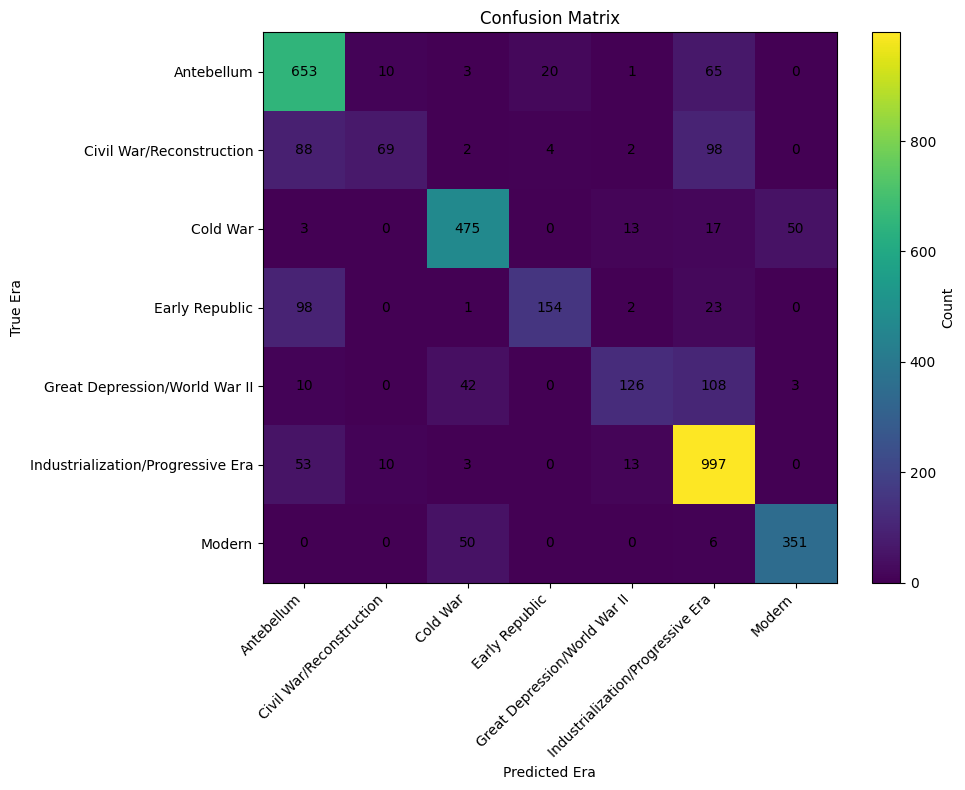

In [35]:
import matplotlib.pyplot as plt

labels = cm_df.columns

plt.figure(figsize=(10, 8))
plt.imshow(cm_df, aspect='auto')
plt.colorbar(label="Count")

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), cm_df.index)

plt.xlabel("Predicted Era")
plt.ylabel("True Era")
plt.title("Confusion Matrix")

for i in range(len(cm_df.index)):
    for j in range(len(cm_df.columns)):
        plt.text(j, i, cm_df.iloc[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## **Cleaner normalized version**

Percentages to easily compare

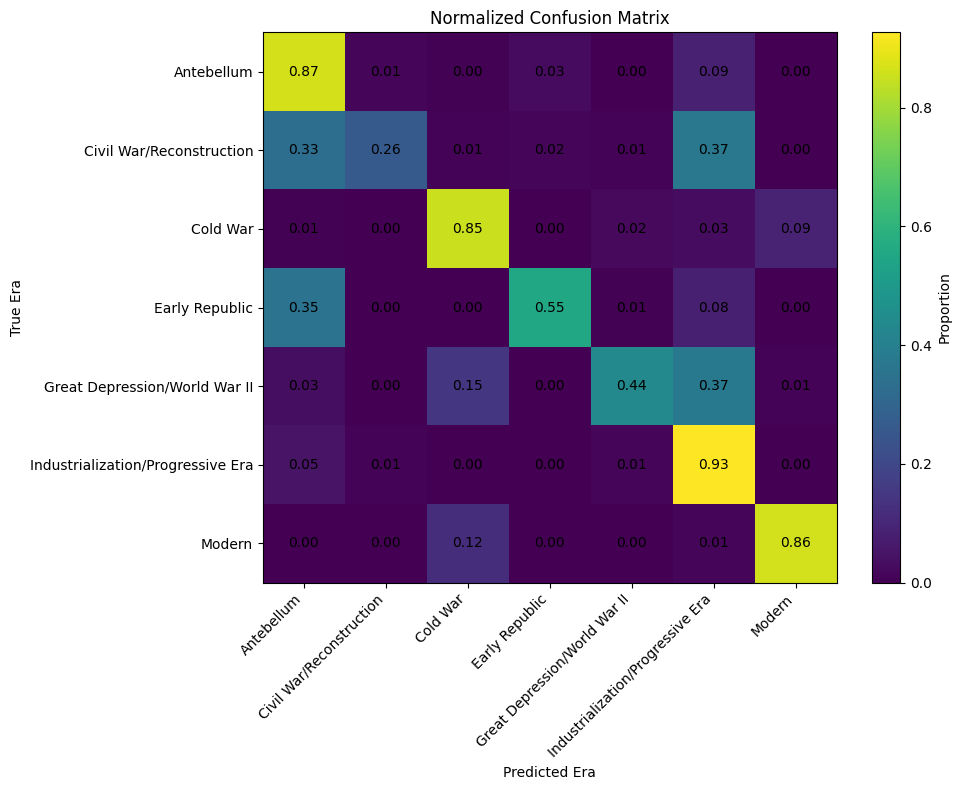

In [36]:
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, aspect='auto')
plt.colorbar(label="Proportion")

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted Era")
plt.ylabel("True Era")
plt.title("Normalized Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{cm_norm.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# **Evaluate the model**

Evaluating precision (true positive/false positive), recall (true postive/true positive + false negative), f1-score (realted to precison ad recall (precision * recall/precision * recall)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7797405465084184

Classification Report:

                                   precision    recall  f1-score   support

                       Antebellum       0.72      0.87      0.79       752
         Civil War/Reconstruction       0.78      0.26      0.39       263
                         Cold War       0.82      0.85      0.84       558
                   Early Republic       0.87      0.55      0.68       278
    Great Depression/World War II       0.80      0.44      0.57       289
Industrialization/Progressive Era       0.76      0.93      0.83      1076
                           Modern       0.87      0.86      0.87       407

                         accuracy                           0.78      3623
                        macro avg       0.80      0.68      0.71      3623
                     weighted avg       0.79      0.78      0.76      3623



# Look at the confusion **matrix**

In [38]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
cm_df = pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_)
print(cm_df)

                                   Antebellum  Civil War/Reconstruction  \
Antebellum                                653                        10   
Civil War/Reconstruction                   88                        69   
Cold War                                    3                         0   
Early Republic                             98                         0   
Great Depression/World War II              10                         0   
Industrialization/Progressive Era          53                        10   
Modern                                      0                         0   

                                   Cold War  Early Republic  \
Antebellum                                3              20   
Civil War/Reconstruction                  2               4   
Cold War                                475               0   
Early Republic                            1             154   
Great Depression/World War II            42               0   
Industrialization/Pro

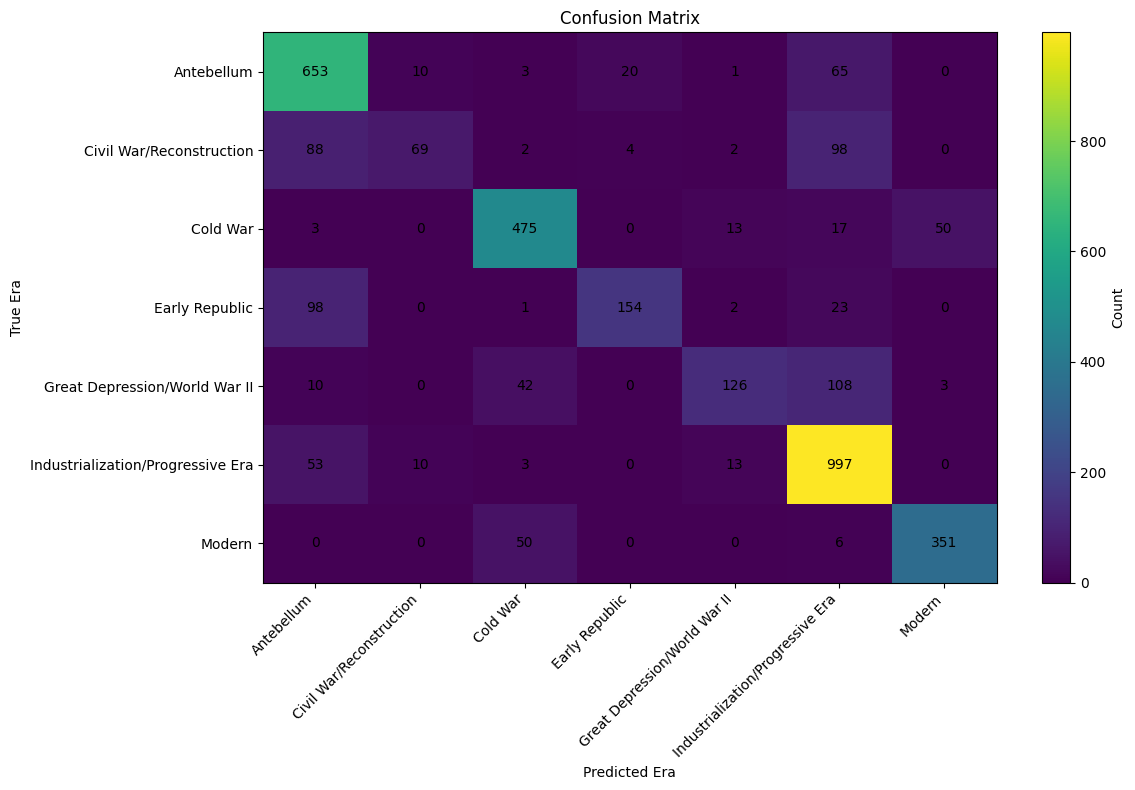

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(cm_df, aspect='auto')
plt.colorbar(label="Count")

plt.xticks(range(len(cm_df.columns)), cm_df.columns, rotation=45, ha="right")
plt.yticks(range(len(cm_df.index)), cm_df.index)

plt.xlabel("Predicted Era")
plt.ylabel("True Era")
plt.title("Confusion Matrix")

for i in range(len(cm_df.index)):
    for j in range(len(cm_df.columns)):
        plt.text(j, i, cm_df.iloc[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [40]:
sample_chunk = """
We have endured hardship, but our nation remains strong, committed to liberty,
economic recovery, and the defense of democratic values around the world.
"""

sample_vec = vectorizer.transform([sample_chunk])
predicted_era = clf.predict(sample_vec)[0]

print("Predicted era:", predicted_era)

Predicted era: Cold War


# Predict the era of a new **chunk**

If new speeches are used this is what the algorithm will do.

In [41]:
def get_top_words(doc, vectorizer, top_n=5):
    doc_tfidf = vectorizer.transform([doc])
    feature_names = vectorizer.get_feature_names_out()
    scores = doc_tfidf.toarray().flatten()

    temp_df = pd.DataFrame({
        "word": feature_names,
        "tfidf": scores
    })

    temp_df = temp_df[temp_df["tfidf"] > 0]
    temp_df = temp_df.sort_values("tfidf", ascending=False)

    return temp_df.head(top_n)

# Get the most important words in a **chunk**

Testing the highest scores to see which words taht adds (deterministic behavior) what the error would be. The most influential words that determines whether it belongs to a particular era

In [ ]:
print(get_top_words(chunked_df["text"].iloc[0], vectorizer, top_n=10))

                 word     tfidf
4422           strong  0.252023
2401       impression  0.200122
2684          lawless  0.192576
2238         guidance  0.192576
2503         inspired  0.190976
4803             vain  0.188741
4838          violate  0.188035
2097        frontiers  0.182391
858   citizens senate  0.179698
1951         feelings  0.178201


# See which words are most associated with each **era**

In [ ]:
feature_names = vectorizer.get_feature_names_out()

for i, era in enumerate(clf.classes_):
    top_indices = clf.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"\nTop words for {era}:")
    print(top_words)


Top words for Antebellum:
['mexico', 'states', 'bank', 'texas', 'duty', 'objects', 'subject', 'character', 'duties', 'minister']

Top words for Civil War/Reconstruction:
['rebellion', 'states', 'currency', 'persons', '1869', 'constitution', 'emancipation', 'proclamation', 'grant', 'slavery']

Top words for Cold War:
['program', 'soviet', 'federal', 'programs', 'inflation', 'world', 'communist', 'economic', 'vietnam', 'million']

Top words for Early Republic:
['militia', 'commerce', 'gentlemen', 'manufactures', 'respecting', 'spain', 'millions', 'effect', 'portion', 'colonies']

Top words for Great Depression/World War II:
['method', 'economic', 'production', 'relief', 'agriculture', 'problems', 'cooperation', 'world', '000', 'problem']

Top words for Industrialization/Progressive Era:
['conditions', 'men', 'silver', 'canal', 'bonds', 'methods', 'arbitration', 'matter', 'international', 'shown']

Top words for Modern:
['america', 'tonight', 'americans', 'applause', 'jobs', 'terrorists'

# Put predictions back into a **DataFrame**

In [ ]:
results_df = pd.DataFrame({
    "text": X_test.values,
    "true_era": y_test.values,
    "predicted_era": y_pred
})

print(results_df.head())

                                                text  \
0  and disgrace. The readiness and efficiency of ...   
1  notified the Olympic Committee that with Sovie...   
2  approval and action upon the coming in of the ...   
3  the end of 1944, the Air Transport Command was...   
4  The Lecompton constitution, which had been thu...   

                            true_era                      predicted_era  
0  Industrialization/Progressive Era  Industrialization/Progressive Era  
1                           Cold War                           Cold War  
2  Industrialization/Progressive Era  Industrialization/Progressive Era  
3      Great Depression/World War II      Great Depression/World War II  
4                         Antebellum                         Antebellum  


# Save the test **predictions**

In [ ]:
results_df.to_csv("era_predictions_test_set.csv", index=False)

In [ ]:
print(results_df)

                                                   text  \
0     and disgrace. The readiness and efficiency of ...   
1     notified the Olympic Committee that with Sovie...   
2     approval and action upon the coming in of the ...   
3     the end of 1944, the Air Transport Command was...   
4     The Lecompton constitution, which had been thu...   
...                                                 ...   
3618  honor whenever and by whatever enemy assailed....   
3619  at the same time removed by allowing the organ...   
3620  have just completed a year's experience with o...   
3621  people and execute its own laws without the in...   
3622  North Africa to deny safe haven to terrorists ...   

                               true_era                      predicted_era  
0     Industrialization/Progressive Era  Industrialization/Progressive Era  
1                              Cold War                           Cold War  
2     Industrialization/Progressive Era  Industrialization/P